In [12]:
import numpy as np

In [13]:
import pandas as pd

In [14]:
from sklearn.cluster import KMeans

In [15]:
import matplotlib.pyplot as plt

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [17]:
num_customers = 1500

In [30]:
data = {'Customers ID':[1,2,3,4,5,6,7,8,9,10], 'Purchase_History':[100,200,300,50,400,150,250,30,500,600], 'Visit_Frequency':[5,10,15,2,20,8,12,1,25,30]} 
        
                                                                                                                    

In [31]:
df=pd.DataFrame(data)

In [32]:
print(df)

   Customers ID  Purchase_History  Visit_Frequency
0             1               100                5
1             2               200               10
2             3               300               15
3             4                50                2
4             5               400               20
5             6               150                8
6             7               250               12
7             8                30                1
8             9               500               25
9            10               600               30


In [33]:
scaler = MinMaxScaler()
df[['Purchase History','Visit Frequency']]=scaler.fit_transform(df[['Purchase_History','Visit_Frequency']])

In [34]:
wcss = []

In [35]:
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(df[['Purchase_History','Visit_Frequency']])
    wcss.append(kmeans.inertia_)

C:\Users\HP\anaconda3\anacondainternship\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\anacondainternship\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\anacondainternship\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\anacondainternship\Lib\site-packages\sklearn\cluster\_kmeans.py:14

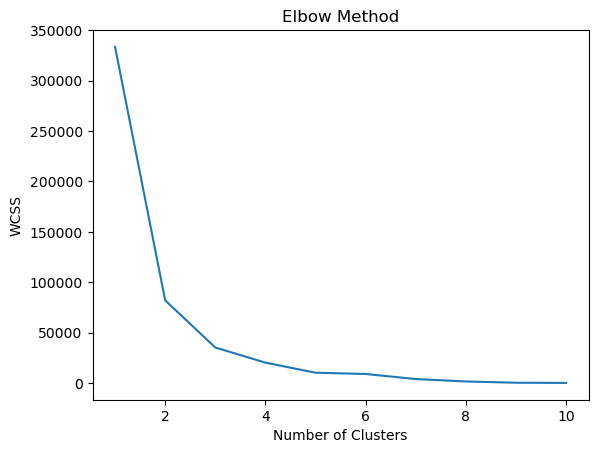

In [36]:
plt.plot(range(1,11),wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()
          

In [37]:
kmeans = KMeans(n_clusters=5,init='k-means++',random_state=42)
kmeans.fit(df[['Purchase_History','Visit_Frequency']])

C:\Users\HP\anaconda3\anacondainternship\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=5, random_state=42)

In [38]:
df['cluster'] = kmeans.labels_

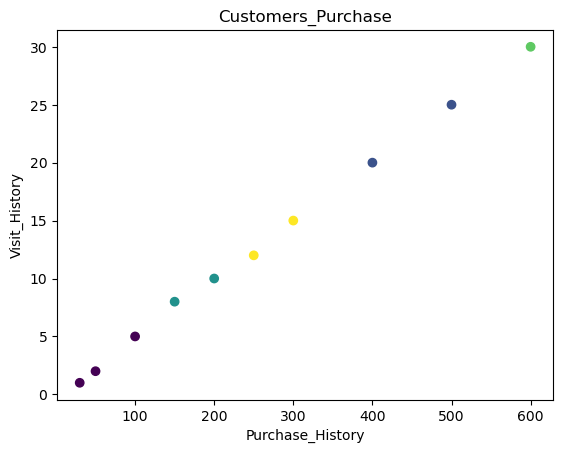

In [41]:
plt.scatter(df['Purchase_History'],df['Visit_Frequency'], c=df['cluster'], cmap='viridis')
plt.title('Customers_Purchase')
plt.xlabel('Purchase_History')
plt.ylabel('Visit_History')
plt.show()